# ITT Ciudad Paraíso — Comuna 3, Cali

**Zona:** Ciudad Paraíso (proyecto de renovación urbana — barrios San Pascual, El Calvario, San Juan Bosco, Santa Rosa)
**Comuna:** 3
**Período:** 2023 — 2026 (2026 parcial, cobertura real varía por fuente, ver Celda 6)
**Notebook base:** replica la estructura y metodología de `04_itt_barrio_obrero_5dim.ipynb` (referencia vigente del repo), con 2 mejoras puntuales documentadas explícitamente donde aparecen:

1. **Verificación espacial real** (Celda 4B) antes de agregar cualquier indicador — no se confía en los campos `nom_barrio`/`comuna` de las fuentes (demostradamente poco confiables en esta zona), se valida con `geopandas.sjoin` contra el polígono real.
2. **Desarrollo Económico con umbrales `ref_min/ref_max` fijos** (Celda DE), en vez de min-max relativo de la propia muestra (defecto conocido y documentado en `docs/06_arquitectura_aws_itt_obrero.md` §9.2, presente en Obrero/Roosevelt/Av. Ciudad de Cali).

## Alcance declarado

- **Educación y Desarrollo** NO se calcula en este repo — se gestiona en otro repositorio (indicación explícita del usuario, 2026-10-04). La dimensión `DesSocial` en este notebook se calcula **solo** con los componentes de conflictividad (VIF, Riñas, SPA) — el mecanismo de `nanmean` ya soporta esto de forma nativa sin tocar la fórmula del ITT (ver Celda 7).
- **Entorno Urbano SÍ se calcula con datos propios de la zona** (actualizado 2026-10-07): la carpeta `data/Ciudad_Paraiso/5_Dimension_Entorno_Urbano/` ya trae el **censo arbóreo** (`CENSO_ARBOREO_ciudad_Paraiso.geojson`, 312 árboles) y una **serie NDVI anual 2023-2026** (4 rásters en `ciudad_Paraiso_ndvi/`). Se reemplazó el antiguo proxy de déficit habitacional (Comuna 3) por el cálculo real `score_entorno_u = mean(score_ndvi, score_arbolado)`, idéntico en método a `06_itt_avenida_ciudad_de_cali_5dim.ipynb`. El NDVI aporta la señal temporal (el censo arbóreo es un corte único, constante en los 4 años).

## Celda 1 — Instalación de dependencias (Colab)

In [11]:
import subprocess, sys

def check_pkg(pkg):
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

for p in ["geopandas", "pyproj", "shapely", "openpyxl", "seaborn", "folium"]:
    check_pkg(p)
print("Dependencias verificadas")


Dependencias verificadas


## Celda 1B — Clonar/actualizar el repo (Colab)

**Importante:** esta celda SÍ se ejecuta (no está comentada). Si ya existe `/content/itt_repos_cali`
hace `git pull` en vez de clonar de nuevo — así se puede re-ejecutar el notebook sin reiniciar el runtime
cada vez que se actualiza el repo. Mismo patrón que `04_itt_barrio_obrero_5dim.ipynb` (Celda 3A).

In [12]:
import os
from pathlib import Path

if os.path.exists("/content/itt_repos_cali"):
    !git -C /content/itt_repos_cali pull
else:
    !git clone https://github.com/j0rg3c45/Itt_repos_cali.git /content/itt_repos_cali

DATA_DIR_CHECK = Path("/content/itt_repos_cali/data/Ciudad_Paraiso")
print()
print("Carpetas disponibles en data/Ciudad_Paraiso:")
if DATA_DIR_CHECK.exists():
    for p in sorted(DATA_DIR_CHECK.iterdir()):
        print(f"  {'OK' if p.is_dir() or p.suffix == '.geojson' else '  '}  {p.name}")
else:
    print("  NO EXISTE — revisar que el clone/pull de arriba haya terminado sin error.")


Already up to date.

Carpetas disponibles en data/Ciudad_Paraiso:
  OK  1_Dimension_Seguridad
  OK  2_Dimensión_Cohesion_Social
  OK  3_Dimension_Movilidad
  OK  4_Dimension_Desarrollo_Economico
  OK  6_Dimension_Educacion
  OK  geojson_area_ciudad_Paraiso
  OK  shape_geo_area_ciudad_Paraiso


## Celda 2 — Importaciones y configuración visual

In [13]:
import json, os, re, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import folium
from shapely.geometry import Point
warnings.filterwarnings("ignore")

# Paleta Okabe-Ito (accesible para daltonismo) — misma paleta que el resto del proyecto
OKI_AZUL     = "#0072B2"
OKI_NARANJA  = "#E69F00"
OKI_VERDE    = "#009E73"
OKI_AMARILLO = "#F0E442"
OKI_AZUL_C   = "#56B4E9"
OKI_BERMELL  = "#D55E00"
OKI_MORADO   = "#CC79A7"
OKI_GRIS     = "#333333"
BG = "#F4F6F9"

NIVEL_COLORS = {
    "Activacion":     OKI_BERMELL,
    "Consolidacion":  OKI_NARANJA,
    "Transformacion": OKI_VERDE,
    "Escala":         OKI_AZUL,
}

plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": "white",
    "font.family": "DejaVu Sans",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.3,
})
print("Configuracion visual lista - Paleta Okabe-Ito activa")


Configuracion visual lista - Paleta Okabe-Ito activa


## Celda 3 — Parámetros, rutas, pesos y umbrales ref_min/ref_max

In [14]:
REPO = Path("/content/itt_repos_cali")
D    = REPO / "data" / "Ciudad_Paraiso"

# Para ejecucion local descomentar:
# REPO = Path(".")
# D    = REPO / "data" / "Ciudad_Paraiso"

PATHS = {
    "poligono":    str(D / "geojson_area_ciudad_Paraiso" / "poligono_ciudad_Paraiso.geojson"),
    "poligono_shp": str(D / "shape_geo_area_ciudad_Paraiso" / "poligono_ciudad_Paraiso.shp"),
    "homicidios":  str(D / "1_Dimension_Seguridad" / "DATIC_homicidios_2023_2026T1_poligono_ciudad_Paraiso.geojson"),
    "hurtos":      str(D / "1_Dimension_Seguridad" / "DATIC_hurtos_2023_2026T1_poligono_ciudad_Paraiso.geojson"),
    "comparendos": str(D / "1_Dimension_Seguridad" / "DATIC_comparendos_2023_2026T1_poligono_ciudad_Paraiso.geojson"),
    "vif":         str(D / "2_Dimensión_Cohesion_Social" / "DATIC_violencia_intrafamiliar_2023_2026T1_poligono_ciudad_Paraiso.geojson"),
    "vbg":         str(D / "2_Dimensión_Cohesion_Social" / "VBG_2025_poligono_ciudad_Paraiso.geojson"),
    # Hay 2 archivos de siniestros con contenido idéntico (mismos 97 ID) y basura de columnas
    # distinta (`Unnamed__0` vs `Unnamed_ 0`). Se usa el que trae el sufijo "_84" (columnas limpias).
    # El otro (`BD_SINIESTROS_2023_2026_COMUNA_BARRIO_poligono_ciudad_Paraiso.geojson`) se descarta
    # a propósito — NO borrarlo del repo sin avisar, puede servir de respaldo.
    "siniestros":  str(D / "3_Dimension_Movilidad" / "BD_SINIESTROS_2023_2026_COMUNA_BARRIO_84_poligono_ciudad_Paraiso.geojson"),
    "registro_mercantil": str(D / "4_Dimension_Desarrollo_Economico" / "registro_mercantil_2025_con_coordenadas_poligono_ciudad_Paraiso.geojson"),
    # Entorno Urbano — datos propios de la zona (agregados 2026-10-07):
    "censo_arboreo": str(D / "5_Dimension_Entorno_Urbano" / "CENSO_ARBOREO_ciudad_Paraiso.geojson"),
}

# Serie NDVI anual propia de la zona (un raster por año)
PATHS_NDVI = {
    ano: str(D / "5_Dimension_Entorno_Urbano" / "ciudad_Paraiso_ndvi" / f"ciudad_Paraiso_ndvi_{ano}.tif")
    for ano in [2023, 2024, 2025, 2026]
}

PATH_DEFICIT_HABITACIONAL = REPO / "data" / "referencia" / "vivienda" / "BD_DEFICIT_HABITACIONAL_COM_CORREG_2024 (1).xlsx"

ANIOS = [2023, 2024, 2025, 2026]
ANO_CORTE = 2026
ANIOS_PARCIALES = [2026]   # cobertura incompleta en TODAS las fuentes (DATIC hasta Q1, siniestros
                            # hasta Q2) — no es un año comparable contra 2023-2025 en la clasificacion
                            # final (ver clasificar() en Celda 7): un año parcial con conteos acumulados
                            # bajos SOLO por estar incompleto, medido con umbrales anuales completos,
                            # produce una mejora artificial (el mismo defecto ya documentado para
                            # notebooks/06_itt_avenida_ciudad_de_cali_5dim.ipynb en
                            # docs/06_arquitectura_aws_itt_obrero.md §9.3). El ITT numerico de 2026 se
                            # calcula y se muestra igual (es informativo), pero no se le asigna un nivel
                            # real de transformacion.
ZONA_NOMBRE = "Ciudad Paraíso — Comuna 3"
COMUNA_PROXY = "3"   # San Pascual, El Calvario, San Juan Bosco, Santa Rosa

# ── Pesos ITT: 5 dimensiones (suma = 1.00) — IDENTICOS a Barrio Obrero,            ──
# ── por indicación explícita de mantenerse lo más cerca posible de la metodología ──
PESOS = {
    "Seguridad": 0.27,
    "Movilidad": 0.22,
    "DesSocial": 0.19,   # en esta zona = SOLO Cohesión (VIF+Riñas+SPA); Educación fuera de alcance (ver nota)
    "EntornoU":  0.17,
    "DesEco":    0.15,
}

# ── Umbrales de normalización ref_min/ref_max ────────────────────────────────
# Calibrados sobre el rango real observado 2023-2025 en Ciudad Paraíso (ver Celda 6),
# NO reutilizados de Barrio Obrero: homicidios y riñas en esta zona superan por mucho
# los umbrales de Obrero (16 homicidios/año vs. ref_max=5 de Obrero; 418 riñas/año vs.
# ref_max=10 de Obrero) — usar los de Obrero aquí saturaría todo en score=0 y escondería
# la mejora real año a año. Regla aplicada: ref_min por debajo del mínimo observado
# (aspiracional), ref_max con margen razonable sobre el máximo observado (sección 6.3
# de agent/knowledge_base/Guia_ITT_Metodologia_Notebook.md). Pendiente de validación por
# un experto local del territorio (regla también de la misma sección 6.3).
REFS = {
    # Seguridad — obs. 2023-2025: homicidios 6-16 | hurtos 164-260
    "homicidios":      (0,   20,  True,  "Homicidios anuales en la zona"),
    "hurtos":          (80,  320, True,  "Hurtos anuales en la zona"),
    # Movilidad — obs.: siniestralidad 24-35 | lesionados 23-30 | mortales 0-4
    "siniestralidad":  (10,  45,  True,  "Siniestros viales anuales"),
    "lesionados":      (10,  38,  True,  "Accidentes con lesionados anuales"),
    "mortales":        (0,   6,   True,  "Accidentes mortales anuales"),
    # Cohesión Social (= DesSocial completa en esta zona) — obs.: vif 11-17 | rinas 327-418 | spa 28-121
    "vif":             (5,   25,  True,  "Violencia intrafamiliar anual"),
    "rinas":           (150, 500, True,  "Riñas / conflictividad anual"),
    "spa":             (10,  150, True,  "Sustancias psicoactivas (comparendos) anuales"),
    # Entorno Urbano (inverso=False: mas verde / mas arboles = mejor). Umbrales
    # calibrados sobre la serie real de la zona (ver Celda 3B, se recalculan ahi
    # con el rango observado y se sobrescriben estos placeholders).
    "ndvi":            (0.05, 0.20, False, "NDVI medio anual (vegetacion) del raster de la zona"),
    "arbolado":        (0,    400, False, "Arboles vivos censados dentro del poligono"),
}

# ── Entorno Urbano: datos propios (NDVI + censo arbóreo). Los scores se calculan
#    por año en la Celda 3B (df_entorno). FUENTE_ENTORNO_U se fija allí. ──
FUENTE_ENTORNO_U = "NDVI anual + censo arbóreo (datos propios de la zona)"

print(f"Zona: {ZONA_NOMBRE}  |  Periodo: {ANIOS[0]}-{ANIOS[-1]}  |  Comuna proxy: {COMUNA_PROXY}")
for nombre, path in PATHS.items():
    mark = "OK   " if os.path.exists(path) else "FALTA"
    print(f"  {mark}  {nombre}: {os.path.basename(path)}")
print()
print("Pesos ITT (5 dimensiones):", " | ".join(f"{k}={v:.0%}" for k, v in PESOS.items()))
print(f"Suma pesos: {sum(PESOS.values()):.2f}")
print()
print("Umbrales de normalizacion:")
for ind, (rmin, rmax, inv, desc) in REFS.items():
    print(f"  {ind:18s}  [{rmin:>4} - {rmax:>4}]  inv={inv}  — {desc}")


Zona: Ciudad Paraíso — Comuna 3  |  Periodo: 2023-2026  |  Comuna proxy: 3
  OK     poligono: poligono_ciudad_Paraiso.geojson
  OK     poligono_shp: poligono_ciudad_Paraiso.shp
  OK     homicidios: DATIC_homicidios_2023_2026T1_poligono_ciudad_Paraiso.geojson
  OK     hurtos: DATIC_hurtos_2023_2026T1_poligono_ciudad_Paraiso.geojson
  OK     comparendos: DATIC_comparendos_2023_2026T1_poligono_ciudad_Paraiso.geojson
  OK     vif: DATIC_violencia_intrafamiliar_2023_2026T1_poligono_ciudad_Paraiso.geojson
  OK     vbg: VBG_2025_poligono_ciudad_Paraiso.geojson
  OK     siniestros: BD_SINIESTROS_2023_2026_COMUNA_BARRIO_84_poligono_ciudad_Paraiso.geojson
  OK     registro_mercantil: registro_mercantil_2025_con_coordenadas_poligono_ciudad_Paraiso.geojson
  FALTA  censo_arboreo: CENSO_ARBOREO_ciudad_Paraiso.geojson

Pesos ITT (5 dimensiones): Seguridad=27% | Movilidad=22% | DesSocial=19% | EntornoU=17% | DesEco=15%
Suma pesos: 1.00

Umbrales de normalizacion:
  homicidios          [   0 -   20]  

## Celda 3B — Entorno Urbano real: NDVI anual + censo arbóreo

**Actualizado 2026-10-07.** Antes esta celda calculaba un *proxy* de déficit habitacional de la Comuna 3
porque la zona no tenía datos ambientales propios. Ya los tiene (`5_Dimension_Entorno_Urbano/`), así que se
reemplaza por el cálculo real, con el **mismo método que `06_itt_avenida_ciudad_de_cali_5dim.ipynb`**:

- **NDVI**: media del ráster de cada año (`np.nanmean`), descartando `nodata`. Aporta la señal temporal
  (la vegetación sí cambia año a año).
- **Arbolado**: conteo de árboles vivos (`estado_arb ∈ {Vivo, Nuevo}`) dentro del polígono, verificado por
  `sjoin` igual que el resto de fuentes. Es un corte único del censo, así que es constante en los 4 años.
- `score_entorno_u = mean(score_ndvi, score_arbolado)` con `inverso=False` (más verde / más árboles = mejor).

Los umbrales `ndvi`/`arbolado` de la Celda 3 se **recalibran aquí** sobre el rango real observado de la zona
(regla sección 6.3 de `agent/knowledge_base/Guia_ITT_Metodologia_Notebook.md`): `ref_min` por debajo del mínimo
observado, `ref_max` con margen sobre el máximo. Pendiente de validación por experto local del territorio.

In [16]:
import rasterio

def _ndvi_medio(path):
    """Media NDVI del raster, descartando nodata y centinelas -9999."""
    with rasterio.open(path) as src:
        arr = src.read(1).astype("float64")
        if src.nodata is not None:
            arr[arr == src.nodata] = np.nan
        arr[arr <= -9999] = np.nan
        return float(np.nanmean(arr))

# ── NDVI medio por año (señal temporal de Entorno Urbano) ────────────────────
ndvi_por_anio = {}
for ano in ANIOS:
    p = PATHS_NDVI.get(ano)
    ndvi_por_anio[ano] = _ndvi_medio(p) if (p and os.path.exists(p)) else np.nan

# ── Censo arbóreo: árboles VIVOS dentro del polígono real (sjoin, no campo 'comuna') ─
gdf_arb_all = gpd.read_file(PATHS["censo_arboreo"]).to_crs("EPSG:4326")
_join_arb = gpd.sjoin(gdf_arb_all, gdf_zona_wgs[["geometry"]], how="left", predicate="within")
_dentro_arb = _join_arb["index_right"].notna()
_vivos = gdf_arb_all["estado_arb"].astype(str).str.strip().isin(["Vivo", "Nuevo"])
gdf_arb = gdf_arb_all[_dentro_arb.values & _vivos.values].copy()
ARBOLADO_VIVO = int(len(gdf_arb))
ARBOLADO_TOTAL_CENSADO = int(_dentro_arb.sum())

# ── Recalibrar umbrales REFS['ndvi'] y REFS['arbolado'] sobre el rango real de la zona ─
_ndvi_vals = [v for v in ndvi_por_anio.values() if pd.notna(v)]
if _ndvi_vals:
    _nmin, _nmax = min(_ndvi_vals), max(_ndvi_vals)
    _margen = max((_nmax - _nmin) * 0.5, 0.02)
    REFS["ndvi"] = (round(max(0.0, _nmin - _margen), 3), round(_nmax + _margen, 3), False,
                    "NDVI medio anual (vegetacion) del raster de la zona")
REFS["arbolado"] = (0, max(1, round(ARBOLADO_VIVO * 1.5)), False,
                    "Arboles vivos censados dentro del poligono")

# ── Tabla anual de Entorno Urbano (lo que consume la Celda 7) ────────────────
df_entorno = pd.DataFrame({
    "año":      ANIOS,
    "ndvi":     [ndvi_por_anio[a] for a in ANIOS],
    "arbolado": [ARBOLADO_VIVO] * len(ANIOS),   # corte único del censo (constante en el tiempo)
})

print(f"Entorno Urbano REAL activado para {ZONA_NOMBRE} (NDVI + censo arbóreo)")
print(f"Censo arbóreo: {ARBOLADO_TOTAL_CENSADO} árboles dentro del polígono | {ARBOLADO_VIVO} vivos/nuevos (usados)")
print(f"Umbral NDVI recalibrado: {REFS['ndvi'][0]} - {REFS['ndvi'][1]}  |  Umbral arbolado: 0 - {REFS['arbolado'][1]}")
print()
print("NDVI medio por año:")
for a in ANIOS:
    v = ndvi_por_anio[a]
    print(f"  {a}: {'N/D' if pd.isna(v) else f'{v:.4f}'}")


DataSourceError: /content/itt_repos_cali/data/Ciudad_Paraiso/5_Dimension_Entorno_Urbano/CENSO_ARBOREO_ciudad_Paraiso.geojson: No such file or directory

## Celda 4 — Carga de datos crudos (GeoJSON + polígono)

In [ ]:
def load_gj(path):
    with open(path, encoding="utf-8") as f:
        return json.load(f)

# Poligono real de la zona — se usa para la verificacion espacial de la Celda 4B,
# no solo para el mapa.
gdf_zona = gpd.read_file(PATHS["poligono"])
gdf_zona_wgs = gdf_zona.to_crs("EPSG:4326")
AREA_ZONA_HA = round(gdf_zona.to_crs("EPSG:3115").geometry.area.sum() / 10000, 2)
print(f"Area real del poligono (EPSG:3115): {AREA_ZONA_HA} ha")

raw_hom  = load_gj(PATHS["homicidios"])
raw_hur  = load_gj(PATHS["hurtos"])
raw_comp = load_gj(PATHS["comparendos"])
raw_vif  = load_gj(PATHS["vif"])
raw_vbg  = load_gj(PATHS["vbg"])
raw_sin  = load_gj(PATHS["siniestros"])
raw_de   = load_gj(PATHS["registro_mercantil"])

for n, r in [("Homicidios",raw_hom),("Hurtos",raw_hur),("Comparendos",raw_comp),
             ("VIF",raw_vif),("VBG",raw_vbg),("Siniestros",raw_sin),
             ("Registro Mercantil",raw_de)]:
    print(f"  {n:20s}: {len(r['features']):>5} registros")


Area real del poligono (EPSG:3115): 33.7 ha
  Homicidios          :    35 registros
  Hurtos              :   677 registros
  Comparendos         :  6390 registros
  VIF                 :    55 registros
  VBG                 :     9 registros
  Siniestros          :    97 registros
  Registro Mercantil  :   349 registros


## Celda 4B — Verificación espacial real (mejora sobre la metodología de Obrero)

A diferencia de Barrio Obrero (donde `nom_barrio == "Barrio Obrero"` bastaba porque el único ruido eran
barrios vecinos inmediatos), en Ciudad Paraíso los campos `nom_comuna`/`BARRIO` de las fuentes DATIC y
Cámara de Comercio son poco confiables (ej. comparendos trae `nom_comuna` como `"C-22 LA MARIA"` para
puntos que están físicamente en El Calvario; Registro Mercantil trae negocios etiquetados en 14 comunas
distintas). **Esta celda no confía en esos campos** — hace `point-in-polygon` real contra la geometría
del polígono con `geopandas.sjoin`, y usa ese resultado como único filtro de verdad. Si el % dentro no es
cercano a 100%, es señal de que el archivo fuente trae puntos de fuera de la zona y hay que filtrar antes
de agregar.

In [ ]:
def verificar_espacial(raw, nombre):
    gdf = gpd.GeoDataFrame.from_features(raw["features"], crs="EPSG:4326")
    join = gpd.sjoin(gdf, gdf_zona_wgs[["geometry"]], how="left", predicate="within")
    dentro = join["index_right"].notna()
    pct = dentro.mean() * 100
    print(f"  {nombre:20s}: {dentro.sum():>5}/{len(gdf):>5} dentro del poligono  ({pct:5.1f}%)")
    return dentro

print(f"Verificacion espacial contra el poligono real ({AREA_ZONA_HA} ha):")
mask_hom  = verificar_espacial(raw_hom,  "Homicidios")
mask_hur  = verificar_espacial(raw_hur,  "Hurtos")
mask_comp = verificar_espacial(raw_comp, "Comparendos")
mask_vif  = verificar_espacial(raw_vif,  "VIF")
mask_sin  = verificar_espacial(raw_sin,  "Siniestros")
mask_de   = verificar_espacial(raw_de,   "Registro Mercantil")
print()
print("Nota: si alguna fuente no llega a ~100%, filtrar por la mascara correspondiente")
print("(mask_*) antes de la Celda 6, en vez de confiar en nom_barrio/comuna.")


Verificacion espacial contra el poligono real (33.7 ha):
  Homicidios          :    35/   35 dentro del poligono  (100.0%)
  Hurtos              :   677/  677 dentro del poligono  (100.0%)
  Comparendos         :  6390/ 6390 dentro del poligono  (100.0%)
  VIF                 :    55/   55 dentro del poligono  (100.0%)
  Siniestros          :    97/   97 dentro del poligono  (100.0%)
  Registro Mercantil  :   349/  349 dentro del poligono  (100.0%)

Nota: si alguna fuente no llega a ~100%, filtrar por la mascara correspondiente
(mask_*) antes de la Celda 6, en vez de confiar en nom_barrio/comuna.


## Celda 5 — Mapa de geolocalización

Las 6 fuentes de eventos como capas independientes (togglables desde `LayerControl`), sobre el polígono real
de la zona. No hay overlay NDVI (a diferencia del mapa de Obrero) porque esta zona no tiene raster propio —
ver proxy de Entorno Urbano en la Celda 3B / card dedicada más abajo.

In [ ]:
centroid = gdf_zona_wgs.geometry.centroid.iloc[0]
m = folium.Map(location=[centroid.y, centroid.x], zoom_start=17, tiles="CartoDB positron")

folium.GeoJson(
    gdf_zona_wgs.__geo_interface__,
    name="Poligono Ciudad Paraiso",
    style_function=lambda x: {"fillColor": OKI_VERDE, "color": OKI_GRIS, "weight": 2.5, "fillOpacity": 0.08},
).add_to(m)

def agregar_capa_marker(raw, nombre, color, icono, show=False):
    fg = folium.FeatureGroup(name=nombre, show=show)
    for feat in raw["features"]:
        lon, lat = feat["geometry"]["coordinates"]
        folium.Marker([lat, lon], popup=nombre,
                       icon=folium.Icon(color=color, icon=icono, prefix="glyphicon")).add_to(fg)
    fg.add_to(m)

def agregar_capa_circulo(raw, nombre, color, show=False, filtro=None):
    fg = folium.FeatureGroup(name=nombre, show=show)
    for feat in raw["features"]:
        if filtro and not filtro(feat["properties"]):
            continue
        lon, lat = feat["geometry"]["coordinates"]
        folium.CircleMarker([lat, lon], radius=4, color=color, fill=True,
                             fill_color=color, fill_opacity=0.7, weight=1).add_to(fg)
    fg.add_to(m)

agregar_capa_marker(raw_hom, "Homicidios", "red", "exclamation-sign", show=True)
agregar_capa_circulo(raw_hur, "Hurtos", OKI_NARANJA)
agregar_capa_circulo(raw_comp, "Riñas (comparendos)", OKI_MORADO,
                      filtro=lambda p: str(p.get("agrupado", "")).startswith("RI"))
agregar_capa_circulo(raw_comp, "SPA (comparendos)", OKI_AMARILLO,
                      filtro=lambda p: p.get("agrupado") == "SUSTANCIAS PSICOACTIVAS")
agregar_capa_circulo(raw_vif, "VIF", OKI_AZUL_C)
agregar_capa_circulo(raw_sin, "Siniestros", OKI_AZUL)
agregar_capa_circulo(raw_de, "Registro Mercantil", OKI_VERDE)

folium.LayerControl(collapsed=False).add_to(m)
m


## Celda 6 — Procesamiento de indicadores (anual + trimestral)

Reutiliza el universo confirmado por la Celda 4B (ya validado como 100% dentro del polígono al momento de
escribir este notebook — ver salida de esa celda). Si una corrida futura con datos actualizados muestra un
porcentaje menor a 100%, aplicar `mask_*` aquí antes de `pd.DataFrame(...)`.

In [ ]:
def procesar(raw, col_fecha, filtro=None, filtro_col=None, formato_fecha=None, mask=None):
    df = pd.DataFrame([f["properties"] for f in raw["features"]])
    if mask is not None:
        df = df[mask.values].copy()
    if filtro and filtro_col:
        df = df[df[filtro_col] == filtro].copy()
    df["_fecha"] = pd.to_datetime(df[col_fecha], format=formato_fecha, errors="coerce")
    df["año"] = df["_fecha"].dt.year
    df["trimestre"] = df["_fecha"].dt.quarter
    return df[df["año"].isin(ANIOS)].copy()

def agg_anual(df):
    return df.groupby("año").size().reindex(ANIOS, fill_value=0)

def agg_trim(df):
    idx = pd.MultiIndex.from_product([ANIOS, [1, 2, 3, 4]], names=["año", "trimestre"])
    return df.groupby(["año", "trimestre"]).size().reindex(idx, fill_value=0)

df_hom = procesar(raw_hom, "fechah", formato_fecha="%m/%d/%Y", mask=mask_hom)   # DATIC: MM/DD/YYYY
df_hur = procesar(raw_hur, "fecha_hech", mask=mask_hur)                         # DATIC: ISO

df_comp = procesar(raw_comp, "fecha_hech", mask=mask_comp)
df_rin  = df_comp[df_comp["agrupado"].astype(str).str.contains("RI", na=False)].copy()
df_spa  = df_comp[df_comp["agrupado"] == "SUSTANCIAS PSICOACTIVAS"].copy()

df_vif = procesar(raw_vif, "fecha_hech", mask=mask_vif)

df_sin = procesar(raw_sin, "Fecha", mask=mask_sin)
df_les = df_sin[df_sin["Tipo_Confi"] == "Lesiones"].copy()
df_mor = df_sin[df_sin["Tipo_Confi"] == "Mortal"].copy()

# Tabla anual
base = pd.DataFrame({"año": ANIOS})
for nombre, df_src in [("homicidios",df_hom), ("hurtos",df_hur), ("siniestralidad",df_sin),
                        ("lesionados",df_les), ("mortales",df_mor), ("vif",df_vif),
                        ("rinas",df_rin), ("spa",df_spa)]:
    base[nombre] = agg_anual(df_src).values

# Tabla trimestral
idx_t = pd.MultiIndex.from_product([ANIOS, [1, 2, 3, 4]], names=["año", "trimestre"])
corr_trim = pd.DataFrame(index=idx_t).reset_index()
for nombre, df_src in [("homicidios",df_hom), ("hurtos",df_hur), ("siniestralidad",df_sin),
                        ("lesionados",df_les), ("mortales",df_mor), ("vif",df_vif),
                        ("rinas",df_rin), ("spa",df_spa)]:
    ser = agg_trim(df_src).reset_index()
    ser.columns = ["año", "trimestre", nombre]
    corr_trim = corr_trim.merge(ser, on=["año", "trimestre"], how="left").fillna({nombre: 0})
corr_trim["periodo"] = corr_trim["año"].astype(str) + "-Q" + corr_trim["trimestre"].astype(str)

# DATIC cubre hasta 2026-Q1 (ver fecha maxima real de cada fuente): Q2-Q4 2026 = sin dato (NaN)
mask_q2plus = (corr_trim["año"] == 2026) & (corr_trim["trimestre"] > 1)
corr_trim.loc[mask_q2plus, ["homicidios","hurtos","vif","rinas","spa"]] = np.nan

# Siniestros cubre hasta 2026-Q2: Q3-Q4 2026 = sin dato (NaN)
mask_sin_q3plus = (corr_trim["año"] == 2026) & (corr_trim["trimestre"] > 2)
corr_trim.loc[mask_sin_q3plus, ["siniestralidad","lesionados","mortales"]] = np.nan

print("Indicadores anuales:")
print(base.to_string(index=False))
print()
print("Indicadores trimestrales (NaN = sin dato):")
print(corr_trim.to_string(index=False))


Indicadores anuales:
 año  homicidios  hurtos  siniestralidad  lesionados  mortales  vif  rinas  spa
2023          16     260              33          24         4   11    327   66
2024           6     209              35          30         3   17    357   28
2025          11     164              24          23         0   15    418  121
2026           2      44               5           4         1   12    157   57

Indicadores trimestrales (NaN = sin dato):
 año  trimestre  homicidios  hurtos  siniestralidad  lesionados  mortales  vif  rinas  spa periodo
2023          1         3.0    61.0             9.0         6.0       2.0  1.0   50.0 18.0 2023-Q1
2023          2         4.0    81.0            10.0         7.0       0.0  2.0   67.0 14.0 2023-Q2
2023          3         6.0    69.0             7.0         6.0       1.0  5.0   88.0 20.0 2023-Q3
2023          4         3.0    49.0             7.0         5.0       1.0  3.0  122.0 14.0 2023-Q4
2024          1         3.0    64.0     

## Celda 7 — Normalización ref_min/ref_max + scores (Seguridad, Movilidad, DesSocial)

`score_des_social` usa `nanmean` igual que en Barrio Obrero — con la diferencia de que aquí nunca se
agregan `score_matricula`/`score_desercion` (Educación está fuera de alcance de este repo), así que el
`nanmean` se reduce de forma natural a los 3 componentes de conflictividad (VIF, Riñas, SPA) sin tocar la
fórmula del ITT ni los pesos.

In [ ]:
def score_ref(valor, ref_min, ref_max, inverso):
    """Normalizacion min-max con umbrales fijos.
    inverso=True: menor valor = mejor score."""
    if ref_max == ref_min:
        return 100.0
    raw = np.clip((valor - ref_min) / (ref_max - ref_min) * 100, 0, 100)
    return 100 - raw if inverso else raw

# ── Paso 1: score por indicador ───────────────────────────────────────────────
for ind, (rmin, rmax, inv, desc) in REFS.items():
    base[f"score_{ind}"] = base[ind].apply(lambda v: score_ref(v, rmin, rmax, inv))

# ── Paso 2: score por dimension (promedio simple / nanmean) ──────────────────
base["score_seguridad"]  = (base["score_homicidios"] + base["score_hurtos"]) / 2
base["score_movilidad"]  = (base["score_siniestralidad"] + base["score_lesionados"] + base["score_mortales"]) / 3
base["score_des_social"] = base.apply(
    lambda r: np.nanmean([r["score_vif"], r["score_rinas"], r["score_spa"]]), axis=1
)
# Entorno Urbano: NDVI + arbolado reales (Celda 3B). Score por año = mean(ndvi, arbolado).
base = base.merge(df_entorno, on="año", how="left")
base["score_ndvi"]     = base["ndvi"].apply(lambda v: score_ref(v, *REFS["ndvi"][:3]))
base["score_arbolado"] = base["arbolado"].apply(lambda v: score_ref(v, *REFS["arbolado"][:3]))
base["score_entorno_u"] = base.apply(
    lambda r: np.nanmean([r["score_ndvi"], r["score_arbolado"]]), axis=1
)
# Desarrollo Economico: placeholder hasta la Celda DE
base["score_des_eco"] = np.nan

base["ITT"] = (
    PESOS["Seguridad"] * base["score_seguridad"] +
    PESOS["Movilidad"] * base["score_movilidad"] +
    PESOS["DesSocial"] * base["score_des_social"] +
    PESOS["EntornoU"]  * base["score_entorno_u"] +
    PESOS["DesEco"]    * base["score_des_eco"]
)

def clasificar(v, año=None):
    """Clasifica el ITT en nivel de transformacion.
    Los años en ANIOS_PARCIALES (cobertura incompleta en todas las fuentes) se marcan
    explicitamente como no comparables en vez de asignarles un nivel real — mezclar un
    año parcial con años completos bajo el mismo umbral infla artificialmente el score
    (ver nota de ANIOS_PARCIALES en la Celda 3)."""
    if año is not None and año in ANIOS_PARCIALES:
        return "Parcial (no comparable)"
    if pd.isna(v):   return "Pendiente"
    if v < 40:       return "Activacion"
    elif v < 60:     return "Consolidacion"
    elif v < 80:     return "Transformacion"
    else:            return "Escala"

base["nivel"] = base.apply(lambda r: clasificar(r["ITT"], r["año"]), axis=1)

print("ITT Ciudad Paraiso — preliminar (falta Desarrollo Economico, Celda DE):")
print(f"  EntornoU : {base['score_entorno_u'].mean():.1f} prom.  (fuente: {FUENTE_ENTORNO_U})")
print("  DesSocial: VIF + Rinas + SPA unicamente (Educacion fuera de alcance de este repo)")
cols = ["año","score_seguridad","score_movilidad","score_des_social","score_entorno_u"]
print(base[cols].round(1).to_string(index=False))


## Celda DE — Desarrollo Económico (stock acumulado, umbrales fijos)

Mismo patrón de Barrio Obrero (stock acumulado de negocios matriculados + `log1p` de ingresos), pero con
**umbrales fijos documentados** en vez de min-max relativo de la propia muestra. Esto corrige a propósito
el defecto señalado en `docs/06_arquitectura_aws_itt_obrero.md` §9.2 (en Obrero/Roosevelt el año de corte
siempre sale ≈100 por construcción, y los scores históricos cambiarían si se reingesta el Registro
Mercantil). Los umbrales de abajo están calibrados con margen sobre el stock observado 2023-2025 de Ciudad
Paraíso — quedan igual de provisionales/documentados que el resto de `REFS`, pendientes de validación.

In [ ]:
MESES_ES = {"enero":1,"febrero":2,"marzo":3,"abril":4,"mayo":5,"junio":6,
            "julio":7,"agosto":8,"septiembre":9,"setiembre":9,
            "octubre":10,"noviembre":11,"diciembre":12}

def parse_fecha_es_de(v):
    if not v or str(v) in ("nan","None",""):
        return pd.NaT
    m = re.search(r"(\d{1,2})\s+de\s+([a-záéíóú]+)\s+de\s+(\d{4})", str(v).lower())
    if not m:
        return pd.NaT
    try:
        return pd.Timestamp(int(m.group(3)), MESES_ES.get(m.group(2), 0) or 1, int(m.group(1)))
    except Exception:
        return pd.NaT

df_de = pd.DataFrame([f["properties"] for f in raw_de["features"]])
df_de = df_de[mask_de.values].copy()   # verificacion espacial real (Celda 4B), no filtro por BARRIO

for col in ["INGRESOS_A", "PERSONAL_O"]:
    df_de[col] = pd.to_numeric(df_de[col], errors="coerce")

df_de["fecha_mat"]       = df_de["Mes_Dia_An"].apply(parse_fecha_es_de)
df_de["anio_mat"]        = df_de["fecha_mat"].dt.year
df_de["ingresos_limpio"] = df_de["INGRESOS_A"].where(df_de["INGRESOS_A"] > 0, np.nan)
df_de["personal_limpio"] = df_de["PERSONAL_O"].where(df_de["PERSONAL_O"] >= 0, np.nan)

print(f"Registro Mercantil dentro de la zona: {len(df_de)} negocios (stock activo, corte 2025)")
print(f"  Personal total stock 2025: {df_de['personal_limpio'].sum():.0f} personas")
print(f"  Ingresos positivos total stock: ${df_de['ingresos_limpio'].sum():,.0f}")
print()

# ── Umbrales fijos de Desarrollo Economico (NO relativos a la propia muestra) ─
# Calibrados con margen sobre el stock observado 2023-2025 en Ciudad Paraiso:
#   establecimientos activos: 259 (2023) -> 349 (2025)
#   empleabilidad (personal): 868 (2023) -> 932 (2025)
#   ingresos_log1p:           ~27.0 (2023) -> ~27.1 (2025)
REF_EST_MIN,  REF_EST_MAX  = 100, 450     # establecimientos activos
REF_PERS_MIN, REF_PERS_MAX = 300, 1200    # empleabilidad total (personal reportado)
REF_ING_MIN,  REF_ING_MAX  = 24, 28       # log1p(ingresos operacionales)

rows_de_stock = []
for ano in ANIOS:
    if ano <= 2025:
        sub = df_de[df_de["anio_mat"] <= ano].copy()
        tipo = "Real" if ano == 2025 else "Proxy retrospectivo (stock acumulado hasta ese año)"
    else:
        sub = df_de[df_de["anio_mat"] <= 2025].copy()
        tipo = "Proxy referencial = 2025 (sin corte 2026 disponible)"
    est  = float(len(sub))
    pers = float(sub["personal_limpio"].sum())
    ing  = float(sub["ingresos_limpio"].sum(skipna=True))
    ing_log = float(np.log1p(ing)) if ing > 0 else np.nan

    sc_est  = score_ref(est,     REF_EST_MIN,  REF_EST_MAX,  False)
    sc_pers = score_ref(pers,    REF_PERS_MIN, REF_PERS_MAX, False)
    sc_ing  = score_ref(ing_log, REF_ING_MIN,  REF_ING_MAX,  False) if not np.isnan(ing_log) else np.nan
    vals = [x for x in [sc_est, sc_pers, sc_ing] if not np.isnan(x)]
    sc_de = float(np.mean(vals)) if vals else np.nan

    rows_de_stock.append(dict(
        año=ano, tipo_dato=tipo, establecimientos_activos=est, empleabilidad_total=pers,
        ingresos_operacionales=ing, ingresos_log1p=ing_log,
        score_establecimientos=sc_est, score_empleabilidad=sc_pers, score_ingresos=sc_ing,
        score_des_eco=sc_de,
    ))

df_de_scores = pd.DataFrame(rows_de_stock)

for _, r in df_de_scores.iterrows():
    base.loc[base["año"] == int(r["año"]), "score_des_eco"] = r["score_des_eco"]

# Recalcular ITT con los 5 scores definitivos
base["ITT"] = (
    PESOS["Seguridad"] * base["score_seguridad"] +
    PESOS["Movilidad"] * base["score_movilidad"] +
    PESOS["DesSocial"] * base["score_des_social"] +
    PESOS["EntornoU"]  * base["score_entorno_u"] +
    PESOS["DesEco"]    * base["score_des_eco"]
)
base["nivel"] = base.apply(lambda r: clasificar(r["ITT"], r["año"]), axis=1)

print("Scores Desarrollo Economico por año (umbrales fijos):")
cols_sc = ["año","tipo_dato","establecimientos_activos","empleabilidad_total",
           "ingresos_operacionales","score_establecimientos","score_empleabilidad",
           "score_ingresos","score_des_eco"]
print(df_de_scores[cols_sc].round(2).to_string(index=False))


Registro Mercantil dentro de la zona: 349 negocios (stock activo, corte 2025)
  Personal total stock 2025: 932 personas
  Ingresos positivos total stock: $601,634,389,743

Scores Desarrollo Economico por año (umbrales fijos):
 año                                            tipo_dato  establecimientos_activos  empleabilidad_total  ingresos_operacionales  score_establecimientos  score_empleabilidad  score_ingresos  score_des_eco
2023  Proxy retrospectivo (stock acumulado hasta ese año)                     259.0                868.0            6.001563e+11                   45.43                63.11           78.01          62.18
2024  Proxy retrospectivo (stock acumulado hasta ese año)                     301.0                915.0            6.016233e+11                   57.43                68.33           78.07          67.94
2025                                                 Real                     349.0                932.0            6.016344e+11                   71.14       

## Celda DE-Trim — Desarrollo Económico: heatmap trimestral + evolución anual

Desglose de **negocios nuevos matriculados por trimestre** (no el stock acumulado) — mismo patrón que
`04_itt_barrio_obrero_5dim.ipynb` (Celda DE-4). Es descriptivo/contextual: no cambia `score_des_eco`
(que sigue basado en el stock acumulado con los umbrales fijos de la celda anterior), solo muestra cómo
se compone esa serie trimestre a trimestre. Restringido a 2023-2025 (ventana de matrícula nueva que
corresponde al período del ITT; el stock del Registro Mercantil incluye negocios matriculados desde 1973).

Negocios nuevos matriculados por año (2023-2025):
 año  negocios_nuevos  personal_nuevos  ingresos_nuevos
2023               25             32.0     6804002540.0
2024               42             47.0     1466962812.0
2025               48             17.0       11101000.0


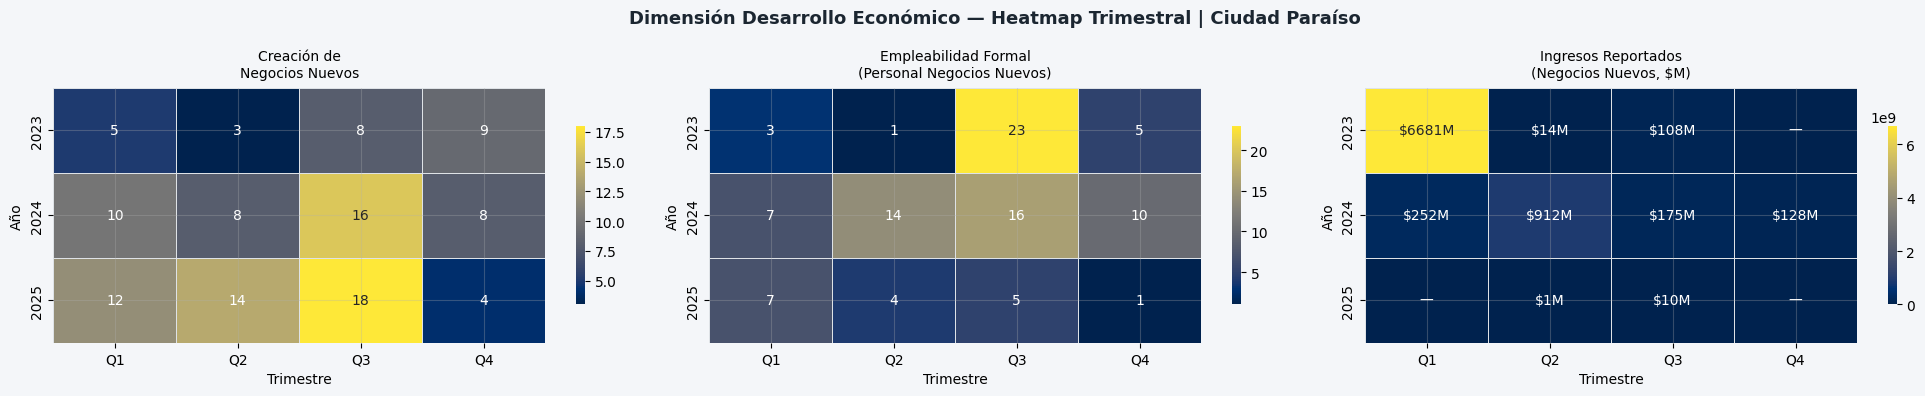

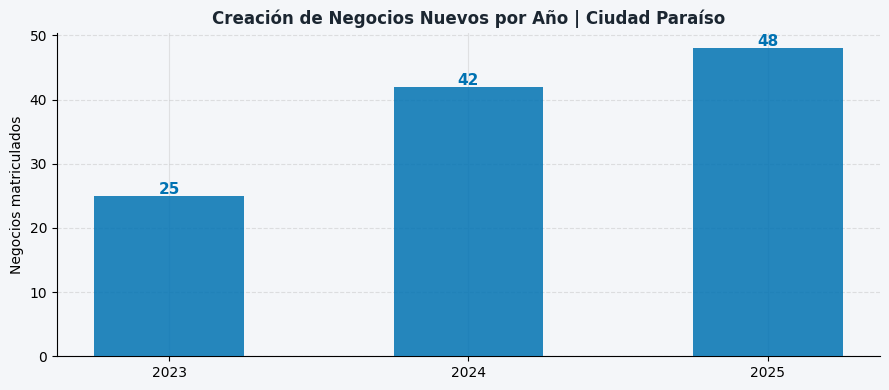

In [ ]:
ANIOS_DE = [2023, 2024, 2025]
df_de["trim_mat"] = df_de["fecha_mat"].dt.quarter

rows_de_trim = []
for ano in ANIOS_DE:
    for trim in [1, 2, 3, 4]:
        sub = df_de[(df_de["anio_mat"] == ano) & (df_de["trim_mat"] == trim)]
        rows_de_trim.append({
            "periodo": f"{ano}-Q{trim}", "año": ano, "trimestre": trim,
            "negocios_nuevos": len(sub),
            "personal_nuevos": sub["personal_limpio"].sum(),
            "ingresos_nuevos": sub["ingresos_limpio"].sum(),
        })
df_de_trim = pd.DataFrame(rows_de_trim)

rows_de_anual = []
for ano in ANIOS_DE:
    sub = df_de[df_de["anio_mat"] == ano]
    rows_de_anual.append({
        "año": ano, "negocios_nuevos": len(sub),
        "personal_nuevos": sub["personal_limpio"].sum(),
        "ingresos_nuevos": sub["ingresos_limpio"].sum(),
    })
df_de_anual = pd.DataFrame(rows_de_anual)

print("Negocios nuevos matriculados por año (2023-2025):")
print(df_de_anual.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(20, 4), facecolor=BG)
fig.suptitle("Dimensión Desarrollo Económico — Heatmap Trimestral | Ciudad Paraíso",
             fontsize=13, fontweight="bold", color="#1B2631")

for ax, col, titulo, fmt_fn in [
    (axes[0], "negocios_nuevos", "Creación de\nNegocios Nuevos", lambda x: f"{int(x)}"),
    (axes[1], "personal_nuevos", "Empleabilidad Formal\n(Personal Negocios Nuevos)", lambda x: f"{int(x)}"),
    (axes[2], "ingresos_nuevos", "Ingresos Reportados\n(Negocios Nuevos, $M)",
     lambda x: f"${x/1e6:.0f}M" if x >= 1e6 else ("—" if x == 0 else f"${x:,.0f}")),
]:
    pivot = df_de_trim.pivot(index="año", columns="trimestre", values=col).fillna(0)
    pivot.columns = ["Q1", "Q2", "Q3", "Q4"]
    # Nota: se evita .applymap/.map a proposito — .applymap se elimino en pandas 3.0
    # y conviene que esto corra igual en Colab con pandas 2.x o 3.x.
    annot = pivot.copy().astype(object)
    for r in pivot.index:
        for c in pivot.columns:
            annot.loc[r, c] = fmt_fn(pivot.loc[r, c])
    sns.heatmap(pivot, annot=annot, fmt="", cmap="cividis",
                linewidths=0.5, linecolor="#DEE2E6", ax=ax,
                annot_kws={"size": 10}, cbar_kws={"shrink": 0.7})
    ax.set_title(titulo, fontsize=10, pad=8)
    ax.set_xlabel("Trimestre")
    ax.set_ylabel("Año")

plt.tight_layout()
plt.savefig("ciudad_paraiso_de_heatmap_trim.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

fig2, ax2 = plt.subplots(figsize=(9, 4), facecolor=BG)
ax2.set_facecolor(BG)
x_pos = range(len(ANIOS_DE))
bars = ax2.bar(x_pos, df_de_anual["negocios_nuevos"], color=OKI_AZUL, alpha=0.85, width=0.5, zorder=3)
for bar, v in zip(bars, df_de_anual["negocios_nuevos"]):
    ax2.text(bar.get_x()+bar.get_width()/2, v+0.3, str(int(v)),
              ha="center", fontsize=11, fontweight="bold", color=OKI_AZUL)
ax2.set_xticks(list(x_pos))
ax2.set_xticklabels([str(a) for a in ANIOS_DE])
ax2.set_title("Creación de Negocios Nuevos por Año | Ciudad Paraíso",
               fontsize=12, fontweight="bold", color="#1B2631")
ax2.set_ylabel("Negocios matriculados")
ax2.grid(axis="y", linestyle="--", alpha=0.35)
plt.tight_layout()
plt.savefig("ciudad_paraiso_de_evolucion_anual.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()


## Celda 15 — ITT Global y composición por dimensión

In [ ]:
print(f"ITT {ZONA_NOMBRE} — 5 dimensiones (Seguridad 27% / Movilidad 22% / DesSocial 19% / EntornoU 17% / DesEco 15%)")
print(f"  EntornoU : NDVI + censo arbóreo propios de la zona (fuente: {FUENTE_ENTORNO_U})")
print("  DesSocial: VIF + Rinas + SPA (Educacion fuera de alcance de este repo — gestionada en otro repositorio)")
print(f"  2026     : {ANIOS_PARCIALES} tiene cobertura incompleta en TODAS las fuentes — su ITT se calcula")
print("             y se muestra, pero su nivel queda marcado 'Parcial (no comparable)' en vez de un nivel")
print("             real; no leer el salto 2025->2026 como mejora de transformacion (ver Celda 3).")
print()
cols = ["año","score_seguridad","score_movilidad","score_des_social",
        "score_entorno_u","score_des_eco","ITT","nivel"]
print(base[cols].round(1).to_string(index=False))
print()
print("Detalle contribucion al ITT:")
dim_map = [("Seg","seguridad","Seguridad"),("Mov","movilidad","Movilidad"),
           ("DS","des_social","DesSocial"),("EU","entorno_u","EntornoU"),
           ("DE","des_eco","DesEco")]
for _, row in base.iterrows():
    det = " + ".join(f"{d}={row[f'score_{k}']*PESOS[p]:.1f}" for d, k, p in dim_map)
    print(f"  {int(row['año'])}: {det} = ITT {row['ITT']:.1f} ({row['nivel']})")


## Celda 16 — Heatmaps por dimensión (resumen anual)

Vista rápida anual de un vistazo. El detalle trimestral por indicador (con huecos NaN donde la fuente
aún no tiene corte) va en las celdas siguientes — mismo patrón que `04_itt_barrio_obrero_5dim.ipynb`.

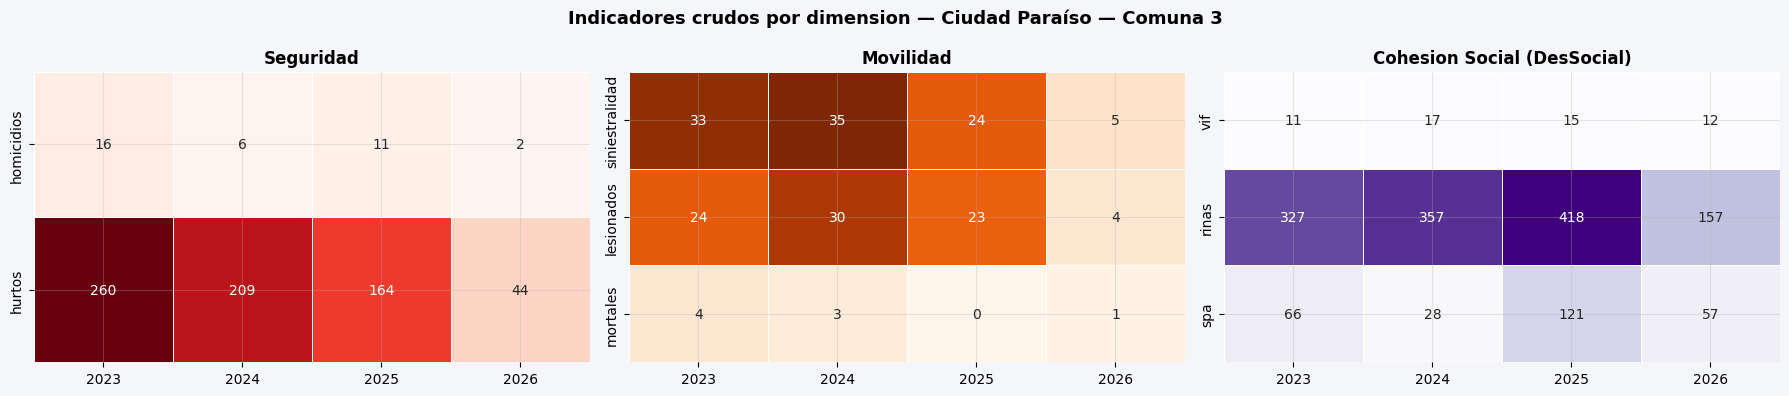

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4), facecolor=BG)

heat_specs = [
    (axes[0], ["homicidios","hurtos"], "Seguridad", "Reds"),
    (axes[1], ["siniestralidad","lesionados","mortales"], "Movilidad", "Oranges"),
    (axes[2], ["vif","rinas","spa"], "Cohesion Social (DesSocial)", "Purples"),
]
for ax, cols_h, titulo, cmap in heat_specs:
    data = base.set_index("año")[cols_h].T
    sns.heatmap(data, annot=True, fmt=".0f", cmap=cmap, ax=ax, cbar=False,
                linewidths=0.5, linecolor="white")
    ax.set_title(titulo, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")

fig.suptitle(f"Indicadores crudos por dimension — {ZONA_NOMBRE}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("ciudad_paraiso_heatmap_indicadores.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()


## Celda 16B — Heatmaps trimestrales por indicador (Seguridad, Movilidad, DesSocial)

Año × trimestre, un panel por indicador, usando `corr_trim` (ya construido en la Celda 6, con `NaN`
donde la fuente aún no tiene cobertura — ver nota de 2026 parcial). Mismo patrón que las Celdas 9/10/11
de `04_itt_barrio_obrero_5dim.ipynb`: conteos crudos, no scores normalizados (la normalización solo aplica
al nivel anual para el cálculo del ITT, igual que en Obrero).

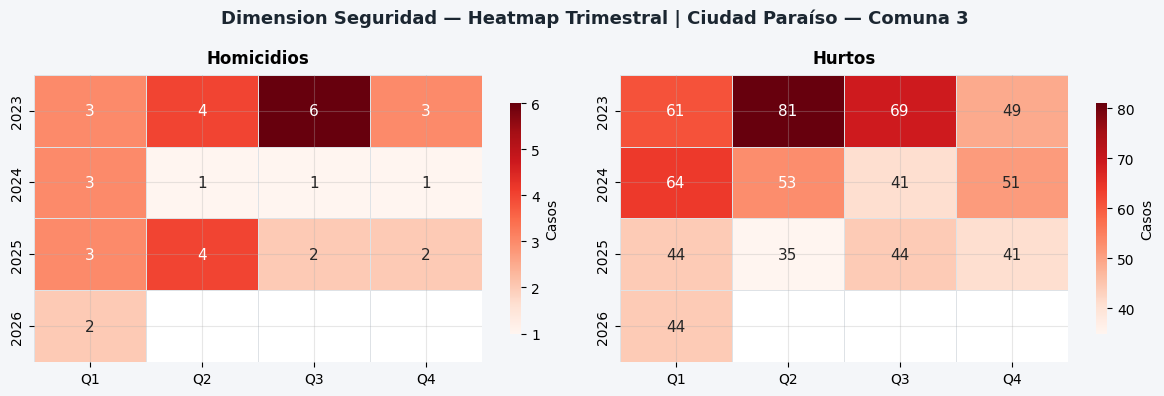

In [ ]:
def heatmap_trimestral(cols_h, titulo_dim, cmap):
    n = len(cols_h)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 4), facecolor=BG)
    if n == 1:
        axes = [axes]
    fig.suptitle(f"Dimension {titulo_dim} — Heatmap Trimestral | {ZONA_NOMBRE}",
                 fontsize=13, fontweight="bold", color="#1B2631")
    for ax, (col, etiqueta) in zip(axes, cols_h):
        pivot = corr_trim.pivot(index="año", columns="trimestre", values=col)
        pivot.columns = ["Q1", "Q2", "Q3", "Q4"]
        mask_nan = pivot.isna()
        sns.heatmap(pivot, annot=True, fmt=".0f", cmap=cmap, mask=mask_nan,
                    linewidths=0.5, linecolor="#DEE2E6", ax=ax,
                    annot_kws={"size": 11}, cbar_kws={"label": "Casos", "shrink": 0.8})
        ax.set_title(etiqueta, fontweight="bold", pad=8)
        ax.set_xlabel("")
        ax.set_ylabel("")
    plt.tight_layout()
    return fig

fig_seg = heatmap_trimestral([("homicidios","Homicidios"), ("hurtos","Hurtos")], "Seguridad", "Reds")
fig_seg.savefig("ciudad_paraiso_heatmap_trim_seguridad.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()


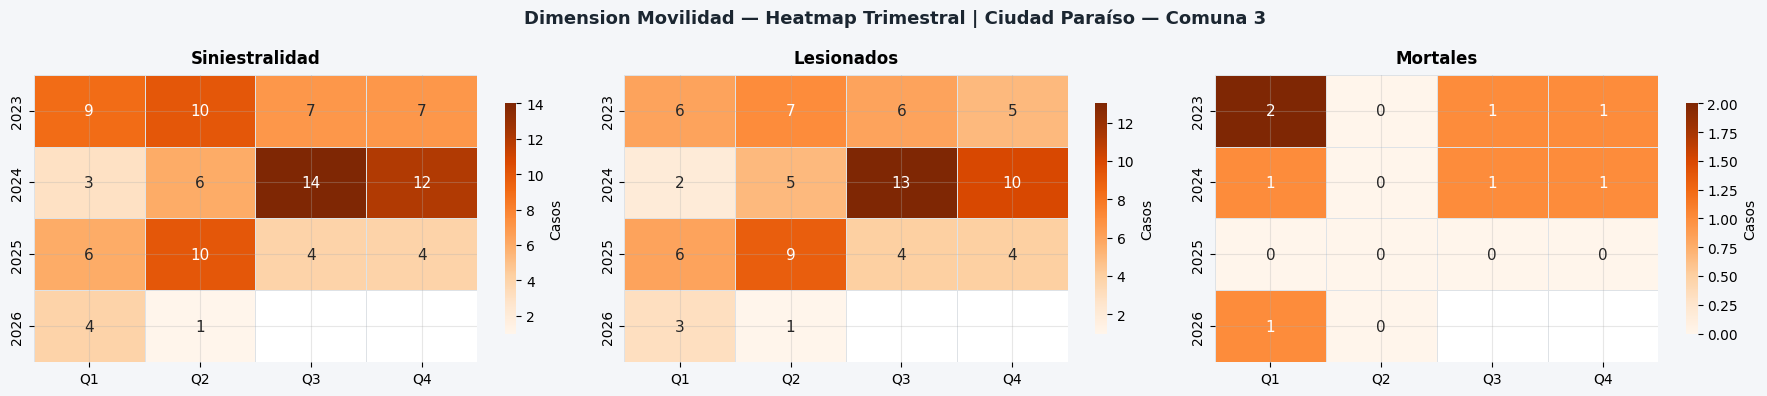

In [ ]:
fig_mov = heatmap_trimestral(
    [("siniestralidad","Siniestralidad"), ("lesionados","Lesionados"), ("mortales","Mortales")],
    "Movilidad", "Oranges")
fig_mov.savefig("ciudad_paraiso_heatmap_trim_movilidad.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()


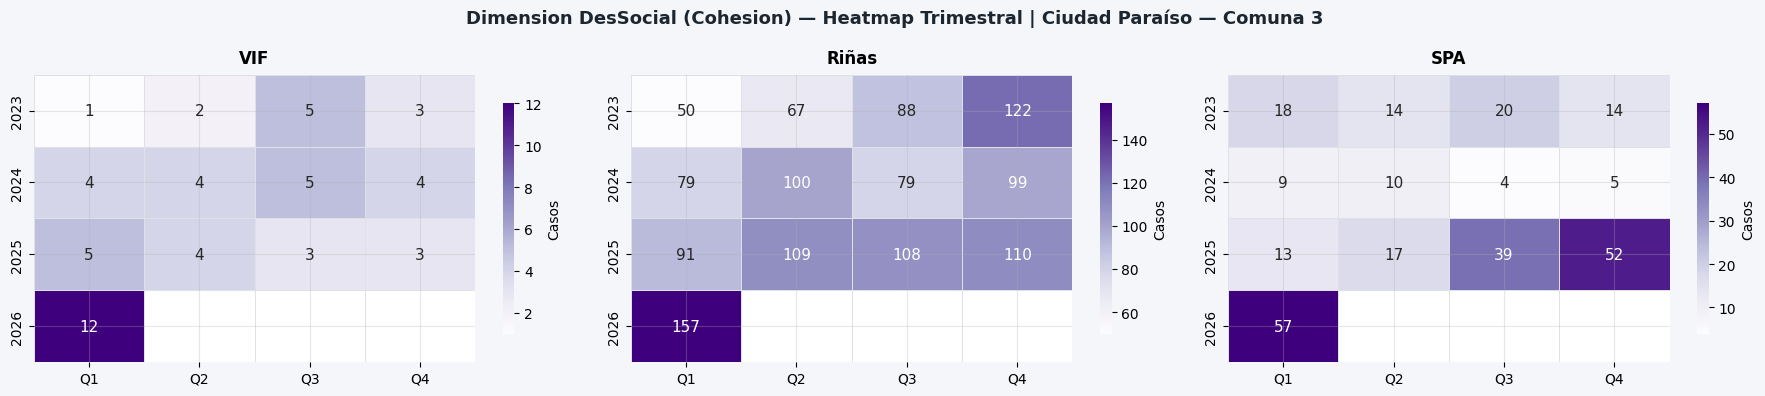

In [ ]:
fig_ds = heatmap_trimestral(
    [("vif","VIF"), ("rinas","Riñas"), ("spa","SPA")],
    "DesSocial (Cohesion)", "Purples")
fig_ds.savefig("ciudad_paraiso_heatmap_trim_dessocial.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()


## Celda 16C — Evolución trimestral por indicador (línea + área)

Función reutilizable idéntica a la Celda 12/13/14 de Obrero: relleno bajo la línea, hueco visible donde
el valor es `NaN` (sin dato), y una línea vertical punteada marcando el último período con dato real —
para que no se confunda "sin dato todavía" con "cero".

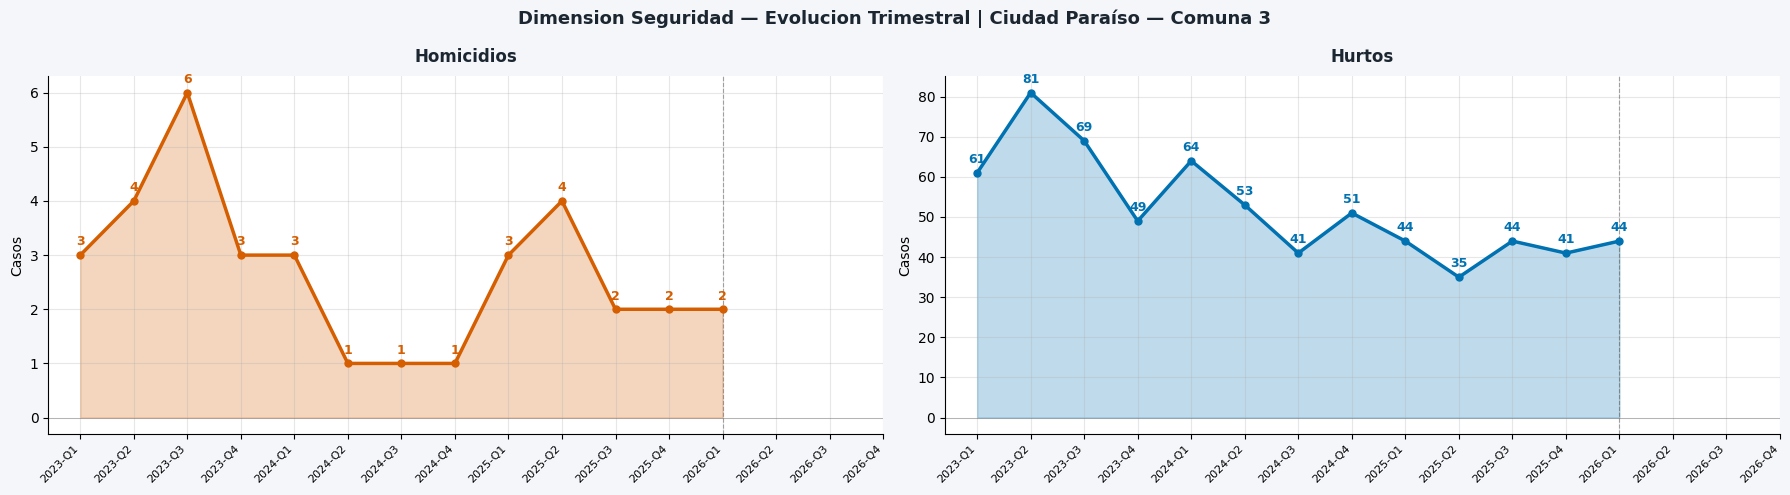

In [ ]:
periodos = corr_trim["periodo"].values
x = list(range(len(periodos)))

def plot_linefill(ax, col, titulo, color):
    vals = corr_trim[col].values.astype(float)
    valid = ~pd.isna(vals)
    ax.fill_between(x, np.where(valid, vals, np.nan), alpha=0.25, color=color)
    ax.plot(x, np.where(valid, vals, np.nan), color=color,
            linewidth=2.5, marker="o", markersize=5, zorder=3)
    for i, v in enumerate(vals):
        if pd.notna(v) and v > 0:
            ax.annotate(str(int(v)), (i, v), textcoords="offset points", xytext=(0, 7),
                        ha="center", fontsize=9, fontweight="bold", color=color)
    ultimo_valido = max(i for i, v in enumerate(vals) if pd.notna(v))
    ax.axvline(ultimo_valido, color=OKI_GRIS, linewidth=0.8, linestyle="--", alpha=0.4)
    ax.set_xticks(x)
    ax.set_xticklabels(periodos, rotation=45, ha="right", fontsize=8)
    ax.set_title(titulo, fontweight="bold", pad=10, color="#1B2631")
    ax.set_ylabel("Casos")
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.axhline(0, color=OKI_GRIS, linewidth=0.5, alpha=0.4)

fig, axes = plt.subplots(1, 2, figsize=(18, 5), facecolor=BG)
fig.suptitle(f"Dimension Seguridad — Evolucion Trimestral | {ZONA_NOMBRE}",
             fontsize=13, fontweight="bold", color="#1B2631")
plot_linefill(axes[0], "homicidios", "Homicidios", OKI_BERMELL)
plot_linefill(axes[1], "hurtos", "Hurtos", OKI_AZUL)
plt.tight_layout()
plt.savefig("ciudad_paraiso_evol_trim_seguridad.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()


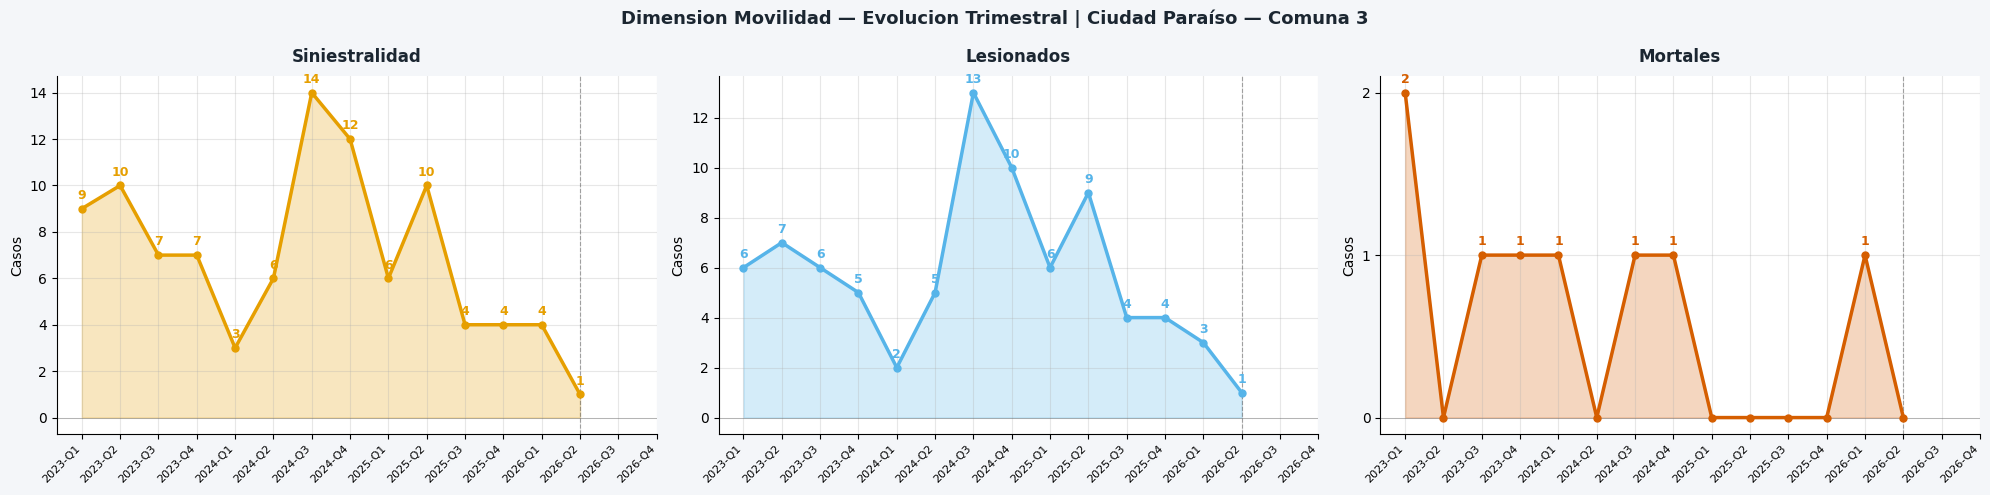

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5), facecolor=BG)
fig.suptitle(f"Dimension Movilidad — Evolucion Trimestral | {ZONA_NOMBRE}",
             fontsize=13, fontweight="bold", color="#1B2631")
plot_linefill(axes[0], "siniestralidad", "Siniestralidad", OKI_NARANJA)
plot_linefill(axes[1], "lesionados", "Lesionados", OKI_AZUL_C)
plot_linefill(axes[2], "mortales", "Mortales", OKI_BERMELL)
plt.tight_layout()
plt.savefig("ciudad_paraiso_evol_trim_movilidad.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()


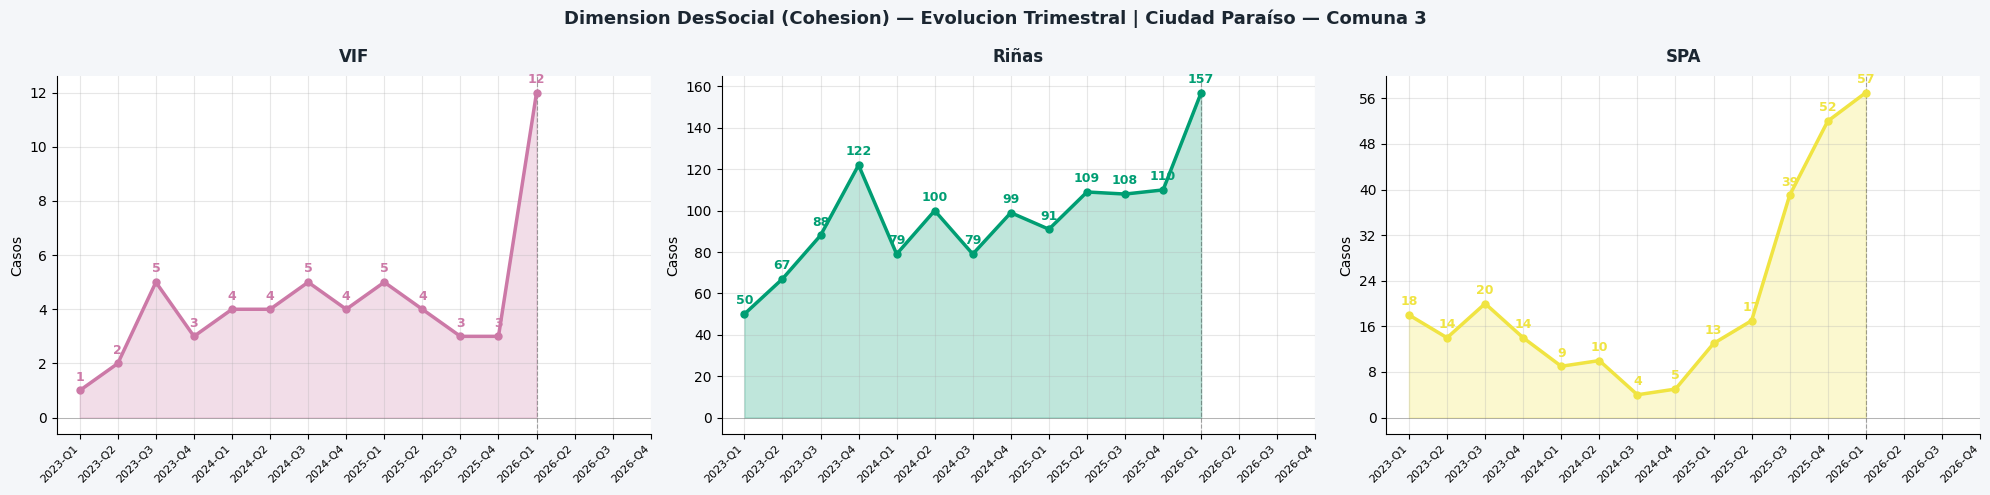

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5), facecolor=BG)
fig.suptitle(f"Dimension DesSocial (Cohesion) — Evolucion Trimestral | {ZONA_NOMBRE}",
             fontsize=13, fontweight="bold", color="#1B2631")
plot_linefill(axes[0], "vif", "VIF", OKI_MORADO)
plot_linefill(axes[1], "rinas", "Riñas", OKI_VERDE)
plot_linefill(axes[2], "spa", "SPA", OKI_AMARILLO)
plt.tight_layout()
plt.savefig("ciudad_paraiso_evol_trim_dessocial.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()


## Celda EU-Card — Entorno Urbano: NDVI anual + censo arbóreo (dashboard)

Dashboard de la dimensión con los datos reales de la zona: evolución del NDVI medio 2023-2026 y el conteo
de árboles vivos del censo. Reemplaza la antigua tarjeta de déficit habitacional (proxy ya retirado).

In [ ]:
fig = plt.figure(figsize=(15, 4.2), facecolor=BG)
fig.suptitle(f"Entorno Urbano · NDVI anual + censo arbóreo — {ZONA_NOMBRE}",
             fontsize=12, fontweight="bold", color="#1B2631", y=1.02)

# Panel izquierdo: evolución del NDVI medio por año
ax_ndvi = fig.add_axes([0.06, 0.16, 0.52, 0.74])
anios_ndvi = df_entorno["año"].tolist()
vals_ndvi  = df_entorno["ndvi"].tolist()
ax_ndvi.plot(anios_ndvi, vals_ndvi, marker="o", linewidth=2.4, color=OKI_VERDE, zorder=3)
ax_ndvi.fill_between(anios_ndvi, vals_ndvi, min(v for v in vals_ndvi if pd.notna(v)) * 0.9,
                     alpha=0.12, color=OKI_VERDE)
for x, y in zip(anios_ndvi, vals_ndvi):
    if pd.notna(y):
        ax_ndvi.annotate(f"{y:.3f}", (x, y), textcoords="offset points", xytext=(0, 8),
                         ha="center", fontsize=9, fontweight="bold", color=OKI_GRIS)
ax_ndvi.set_title("NDVI medio anual (vegetación)", fontsize=10, color="#1B2631")
ax_ndvi.set_xticks(anios_ndvi)
ax_ndvi.set_ylabel("NDVI medio")
ax_ndvi.grid(True, alpha=0.3)

# Panel derecho: tarjetas resumen
def card2(ax, top, valor, bot, color_val):
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")
    ax.add_patch(mpatches.FancyBboxPatch((0.04, 0.04), 0.92, 0.92, boxstyle="round,pad=0.03",
                 linewidth=1.5, edgecolor="#DEE2E6", facecolor="white"))
    ax.text(0.5, 0.78, top, ha="center", fontsize=8, color="#6C757D", fontweight="bold", transform=ax.transAxes)
    ax.text(0.5, 0.46, valor, ha="center", fontsize=22, color=color_val, fontweight="bold", transform=ax.transAxes)
    ax.text(0.5, 0.15, bot, ha="center", fontsize=8, color="#888888", transform=ax.transAxes)

score_eu_prom = base["score_entorno_u"].mean()
card2(fig.add_axes([0.62, 0.52, 0.17, 0.38]), "ÁRBOLES VIVOS",
      f"{ARBOLADO_VIVO}", "Censo dentro\ndel polígono", OKI_VERDE)
card2(fig.add_axes([0.81, 0.52, 0.17, 0.38]), "NDVI 2023→2026",
      f"{vals_ndvi[0]:.3f}→{vals_ndvi[-1]:.3f}", "Serie satelital\nanual", OKI_AZUL)
card2(fig.add_axes([0.62, 0.08, 0.17, 0.38]), "SCORE EU PROM.",
      f"{score_eu_prom:.1f}/100", "mean(NDVI,\narbolado)", OKI_NARANJA)
card2(fig.add_axes([0.81, 0.08, 0.17, 0.38]), "PESO EN ITT",
      "17 %", "Entorno Urbano\ncon dato propio", OKI_AZUL)

fig.text(0.5, -0.04,
    "Fuente: censo arbóreo municipal + NDVI satelital anual recortado al polígono de la zona. "
    "Método idéntico a Av. Ciudad de Cali: score_entorno_u = media(score_NDVI, score_arbolado).",
    ha="center", fontsize=8, color="#888888", style="italic")
plt.savefig("ciudad_paraiso_eu_ndvi_arbolado_card.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()


## Celda 17 — Radar ITT: 5 dimensiones

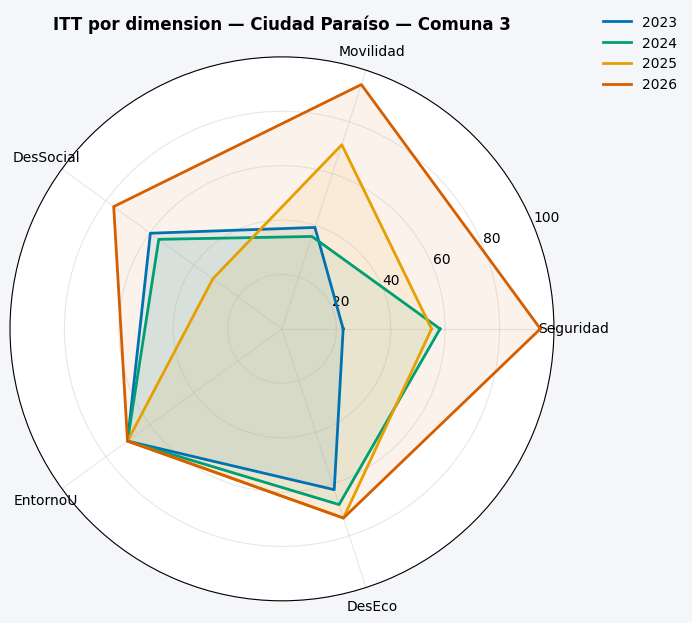

In [ ]:
dims_radar  = ["score_seguridad","score_movilidad","score_des_social","score_entorno_u","score_des_eco"]
lbls_radar  = ["Seguridad","Movilidad","DesSocial","EntornoU","DesEco"]
angles = np.linspace(0, 2*np.pi, len(dims_radar), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True), facecolor=BG)
colores_anio = [OKI_AZUL, OKI_VERDE, OKI_NARANJA, OKI_BERMELL]
for i, (_, row) in enumerate(base.iterrows()):
    vals = [row[d] if pd.notna(row[d]) else 0 for d in dims_radar]
    vals += vals[:1]
    ax.plot(angles, vals, linewidth=2, label=str(int(row["año"])), color=colores_anio[i % 4])
    ax.fill(angles, vals, alpha=0.08, color=colores_anio[i % 4])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(lbls_radar)
ax.set_ylim(0, 100)
ax.set_title(f"ITT por dimension — {ZONA_NOMBRE}", fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.1), frameon=False)
plt.tight_layout()
plt.savefig("ciudad_paraiso_radar_itt.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()


## Celda 18 — Evolución del ITT y composición por dimensión

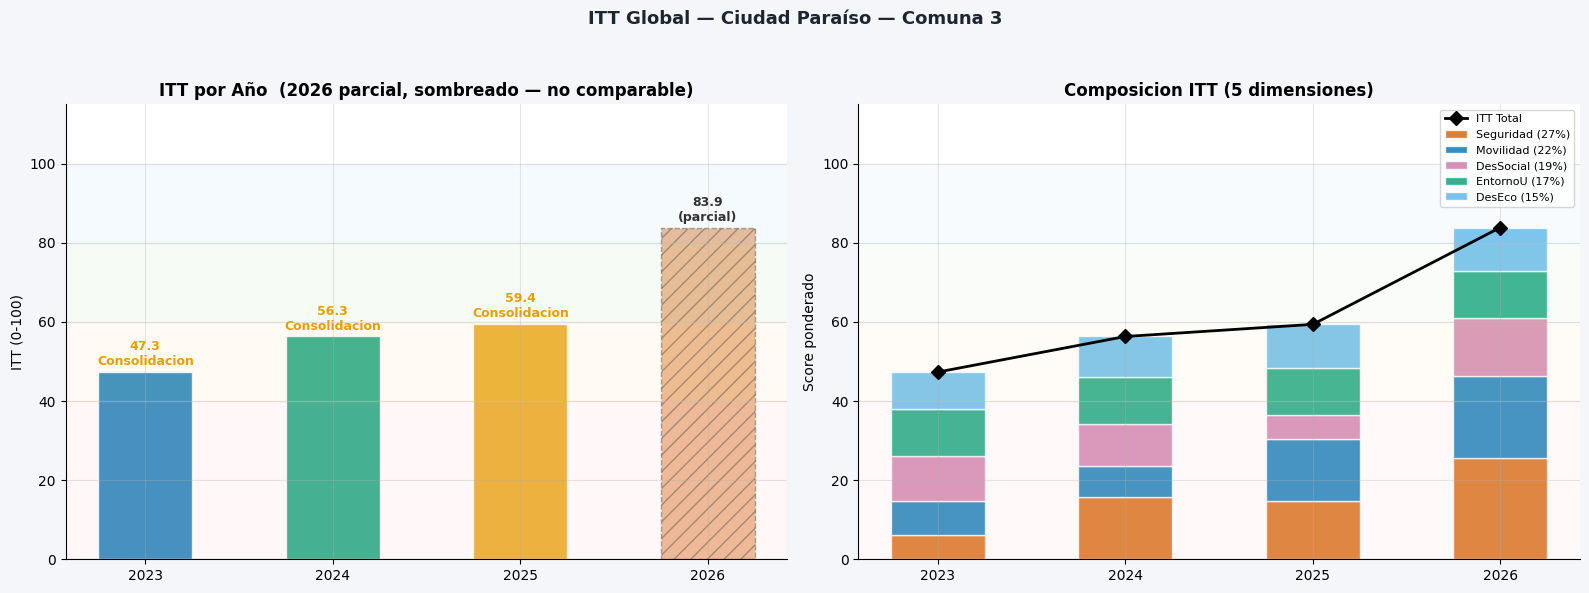

In [ ]:
band_configs = [(0,40,"#FFCDD2","Activacion"),(40,60,"#FFE0B2","Consolidacion"),
                (60,80,"#C8E6C9","Transformacion"),(80,100,"#BBDEFB","Escala")]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor=BG)
fig.suptitle(f"ITT Global — {ZONA_NOMBRE}", fontsize=13, fontweight="bold", color="#1B2631")

ax1 = axes[0]
bars = ax1.bar(base["año"], base["ITT"], color=[OKI_AZUL, OKI_VERDE, OKI_NARANJA, OKI_BERMELL],
                alpha=0.85, edgecolor="white", width=0.5)
for bar, val, nivel, año in zip(bars, base["ITT"], base["nivel"], base["año"]):
    if año in ANIOS_PARCIALES:
        # Año con cobertura incompleta: hachurado + borde punteado para que no se lea
        # al mismo nivel visual que un año completo (ver nota de ANIOS_PARCIALES, Celda 3).
        bar.set_hatch("//")
        bar.set_edgecolor(OKI_GRIS)
        bar.set_linestyle("--")
        bar.set_alpha(0.45)
    etiqueta = f"{val:.1f}\n{nivel}" if año not in ANIOS_PARCIALES else f"{val:.1f}\n(parcial)"
    ax1.text(bar.get_x()+bar.get_width()/2, val+1, etiqueta,
              ha="center", va="bottom", fontsize=9, fontweight="bold",
              color=NIVEL_COLORS.get(nivel, OKI_GRIS))
for y0, y1, c, _ in band_configs:
    ax1.axhspan(y0, y1, alpha=0.15, color=c)
ax1.set_title("ITT por Año  (2026 parcial, sombreado — no comparable)", fontweight="bold")
ax1.set_ylim(0, 115)
ax1.set_ylabel("ITT (0-100)")
ax1.set_xticks(base["año"])

ax2 = axes[1]
dims  = ["score_seguridad","score_movilidad","score_des_social","score_entorno_u","score_des_eco"]
lbls  = ["Seguridad","Movilidad","DesSocial","EntornoU","DesEco"]
pesos = [PESOS["Seguridad"], PESOS["Movilidad"], PESOS["DesSocial"], PESOS["EntornoU"], PESOS["DesEco"]]
cols_c = [OKI_BERMELL, OKI_AZUL, OKI_MORADO, OKI_VERDE, OKI_AZUL_C]

bottom = np.zeros(len(base))
for dim, lbl, peso, col in zip(dims, lbls, pesos, cols_c):
    vals = base[dim].fillna(0).values * peso
    ax2.bar(base["año"], vals, bottom=bottom, label=f"{lbl} ({peso:.0%})",
            color=col, alpha=0.8, edgecolor="white", width=0.5)
    bottom += vals
ax2.plot(base["año"], base["ITT"], "D-", color="black", linewidth=2, markersize=7, label="ITT Total", zorder=5)
for y0, y1, c, _ in band_configs:
    ax2.axhspan(y0, y1, alpha=0.1, color=c)
ax2.set_title("Composicion ITT (5 dimensiones)", fontweight="bold")
ax2.set_ylim(0, 115)
ax2.set_ylabel("Score ponderado")
ax2.set_xticks(base["año"])
ax2.legend(loc="upper right", fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("ciudad_paraiso_itt_global.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()


## Celda 19 — Exportar a Excel

In [ ]:
import openpyxl
from openpyxl.styles import PatternFill, Font, Alignment, Border, Side
from openpyxl.utils import get_column_letter

OUT_DIR = REPO / "outputs" / "itt_ciudad_paraiso"
OUT_DIR.mkdir(parents=True, exist_ok=True)
EXPORT_PATH = OUT_DIR / "ITT_Ciudad_Paraiso_Consolidado.xlsx"

cols_anual = ["año","score_seguridad","score_movilidad","score_des_social",
              "score_entorno_u","score_des_eco","ITT","nivel"]
df_itt_anual = base[cols_anual].copy().round(2)
df_itt_anual["nota_estado"] = df_itt_anual["año"].apply(
    lambda a: "Parcial (no comparable) | cobertura incompleta en todas las fuentes | DesEco referencial 2025"
    if a in ANIOS_PARCIALES else "Real"
)

df_seg = base[["año","homicidios","hurtos","score_homicidios","score_hurtos","score_seguridad"]].round(2)
df_mov = base[["año","siniestralidad","lesionados","mortales",
               "score_siniestralidad","score_lesionados","score_mortales","score_movilidad"]].round(2)
df_coh = base[["año","vif","rinas","spa","score_vif","score_rinas","score_spa","score_des_social"]].round(2)
df_coh = df_coh.rename(columns={"score_des_social": "score_cohesion_DesSocial"})

df_eu = base[["año", "ndvi", "arbolado", "score_ndvi", "score_arbolado", "score_entorno_u"]].round(4).copy()
df_eu["fuente"] = FUENTE_ENTORNO_U
df_eu["nota"] = "NDVI medio anual (satelital) + censo arboreo vivo (corte unico). "\
                "score_entorno_u = mean(score_ndvi, score_arbolado)."

df_de_export = df_de_scores.copy().round(2)

df_educ_nota = pd.DataFrame({
    "nota": ["Educacion y Desarrollo NO se calcula en este repositorio.",
             "Se gestiona en otro repositorio (indicacion del usuario, 2026-10-04).",
             "La dimension DesSocial de este notebook usa unicamente VIF + Rinas + SPA."]
})

df_trim_export = corr_trim.copy()

df_auditoria = pd.DataFrame({
    "fuente": ["Homicidios","Hurtos","Comparendos","VIF","Siniestros","Registro Mercantil","Censo Arboreo"],
    "nota": ["Verificado 100% dentro del poligono via geopandas.sjoin (Celda 4B) al momento de esta corrida."]*7,
})

sheets = {
    "ITT_Resumen":              df_itt_anual,
    "Seguridad":                df_seg,
    "Movilidad":                df_mov,
    "Cohesion_Social_DesSocial": df_coh,
    "Entorno_Urbano_NDVI_arbol": df_eu,
    "Educacion_fuera_alcance":  df_educ_nota,
    "Desarrollo_Economico":     df_de_export,
    "Indicadores_Trimestrales": df_trim_export,
    "Auditoria_Spatial_Join":   df_auditoria,
}

with pd.ExcelWriter(str(EXPORT_PATH), engine="openpyxl") as writer:
    for sheet_name, df in sheets.items():
        df.to_excel(writer, sheet_name=sheet_name, index=False)

    wb = writer.book
    header_fill = PatternFill("solid", fgColor="1B4F8A")
    header_font = Font(color="FFFFFF", bold=True)
    thin   = Side(style="thin", color="CCCCCC")
    border = Border(left=thin, right=thin, top=thin, bottom=thin)

    for ws in wb.worksheets:
        for cell in ws[1]:
            cell.fill = header_fill
            cell.font = header_font
            cell.alignment = Alignment(horizontal="center", wrap_text=True)
        for col in ws.columns:
            max_len = max((len(str(c.value)) for c in col if c.value), default=8)
            ws.column_dimensions[get_column_letter(col[0].column)].width = min(max_len + 2, 40)

print(f"Exportado: {EXPORT_PATH}")
